
# Laporan Proyek Machine Learning - Sistem Rekomendasi Anime

**Nama Anggota:**
- Alvey Reza Pahlevi
- Adriana Syahban

Proyek ini membangun sistem rekomendasi anime menggunakan dua pendekatan utama, yaitu **Content-Based Filtering** dan **Collaborative Filtering**. Sistem rekomendasi ini dibuat untuk membantu pengguna menemukan anime yang sesuai dengan minat atau pola rating pengguna.



## 1. Project Overview

Anime memiliki jumlah judul yang sangat banyak dengan genre, tipe, rating, dan popularitas yang beragam. Banyaknya pilihan tersebut dapat menyulitkan pengguna dalam menentukan anime yang ingin ditonton berikutnya. Oleh karena itu, sistem rekomendasi dibutuhkan untuk membantu pengguna menemukan anime yang lebih relevan dengan preferensi mereka.

Pada proyek ini digunakan **Anime Recommendations Database** yang berisi data anime dan rating pengguna. Proyek ini membandingkan dua pendekatan rekomendasi, yaitu **Content-Based Filtering** dan **Collaborative Filtering**.

Manfaat proyek:
- Membantu pengguna menemukan anime berdasarkan kemiripan genre dan tipe.
- Memberikan rekomendasi personal berdasarkan pola rating pengguna.
- Membandingkan dua pendekatan sistem rekomendasi.



## 2. Business Understanding

### Problem Statements
1. Bagaimana membangun sistem rekomendasi anime yang dapat membantu pengguna menemukan anime sesuai preferensi?
2. Bagaimana menerapkan pendekatan Content-Based Filtering dan Collaborative Filtering pada data anime?
3. Bagaimana membandingkan hasil rekomendasi dari kedua pendekatan tersebut?

### Goals
1. Mengembangkan sistem rekomendasi anime berbasis machine learning.
2. Menerapkan dua pendekatan, yaitu Content-Based Filtering dan Collaborative Filtering.
3. Mengevaluasi hasil rekomendasi berdasarkan kemiripan konten dan error prediksi rating.

### Solution Approach
1. **Content-Based Filtering**  
   Sistem merekomendasikan anime berdasarkan kemiripan fitur seperti judul, genre, dan tipe anime menggunakan TF-IDF dan Cosine Similarity.

2. **Collaborative Filtering**  
   Sistem merekomendasikan anime berdasarkan pola rating pengguna lain yang memiliki kemiripan menggunakan pendekatan user-based collaborative filtering.


In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Library berhasil diimport.")


Library berhasil diimport.



## 3. Data Understanding

Dataset yang digunakan terdiri dari dua file utama:

1. **anime_sample.csv**  
   Berisi informasi anime seperti anime_id, name, genre, type, episodes, rating, dan members.

2. **rating_sample.csv**  
   Berisi data rating pengguna terhadap anime, yaitu user_id, anime_id, dan rating.

Data yang digunakan pada notebook ini merupakan hasil sampling dari dataset asli agar proses pemodelan dan deployment lebih ringan.


In [19]:

anime = pd.read_csv("data_sample/anime_sample.csv")
rating = pd.read_csv("data_sample/rating_sample.csv")

print("Ukuran data anime:", anime.shape)
print("Ukuran data rating:", rating.shape)

display(anime.head())
display(rating.head())


Ukuran data anime: (300, 7)
Ukuran data rating: (103449, 3)


,anime_id,name,genre,type,episodes,rating,members
0,1535,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37,8.71,1013917
1,16498,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25,8.54,896229
2,11757,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25,7.83,893100
3,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
4,6547,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13,8.39,717796


,user_id,anime_id,rating
0,226,1,8
1,226,6,8
2,226,20,7
3,226,45,8
4,226,59,8


In [20]:

print("Informasi data anime:")
display(anime.info())

print("\nInformasi data rating:")
display(rating.info())


Informasi data anime:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  300 non-null    int64  
 1   name      300 non-null    str    
 2   genre     300 non-null    str    
 3   type      300 non-null    str    
 4   episodes  300 non-null    str    
 5   rating    299 non-null    float64
 6   members   300 non-null    int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 35.9 KB


None


Informasi data rating:
<class 'pandas.DataFrame'>
RangeIndex: 103449 entries, 0 to 103448
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user_id   103449 non-null  int64
 1   anime_id  103449 non-null  int64
 2   rating    103449 non-null  int64
dtypes: int64(3)
memory usage: 2.4 MB


None

In [21]:

print("Missing values pada data anime:")
display(anime.isnull().sum())

print("\nMissing values pada data rating:")
display(rating.isnull().sum())


Missing values pada data anime:


anime_id    0
name        0
genre       0
type        0
episodes    0
rating      1
members     0
dtype: int64


Missing values pada data rating:


user_id     0
anime_id    0
rating      0
dtype: int64

In [22]:

print("Statistik deskriptif data anime:")
display(anime.describe(include="all"))

print("\nStatistik deskriptif data rating:")
display(rating.describe())


Statistik deskriptif data anime:


,anime_id,name,genre,type,episodes,rating,members
count,300.000000,300,300,300,300,299.000000,3.000000e+02
unique,NaN,300,248,3,44,NaN,NaN
top,NaN,Death Note,"Comedy, Drama, Romance, School, Slice of Life",TV,12,NaN,NaN
freq,NaN,1,3,277,88,NaN,NaN
mean,11756.673333,NaN,NaN,NaN,NaN,8.013545,2.960966e+05
std,10221.133102,NaN,NaN,NaN,NaN,0.502736,1.422084e+05
min,1.000000,NaN,NaN,NaN,NaN,6.170000,1.644450e+05
25%,1973.000000,NaN,NaN,NaN,NaN,7.675000,1.948390e+05
50%,10034.500000,NaN,NaN,NaN,NaN,8.010000,2.442305e+05
75%,19369.500000,NaN,NaN,NaN,NaN,8.395000,3.386252e+05



Statistik deskriptif data rating:


,user_id,anime_id,rating
count,103449.000000,103449.000000,103449.000000
mean,34674.885209,12107.707015,7.892478
std,20710.957125,9725.361961,1.442586
min,226.000000,1.000000,1.000000
25%,17489.000000,2993.000000,7.000000
50%,32611.000000,10620.000000,8.000000
75%,52587.000000,19163.000000,9.000000
max,73378.000000,32729.000000,10.000000



## 4. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik data, seperti distribusi rating, anime populer, dan genre yang sering muncul.


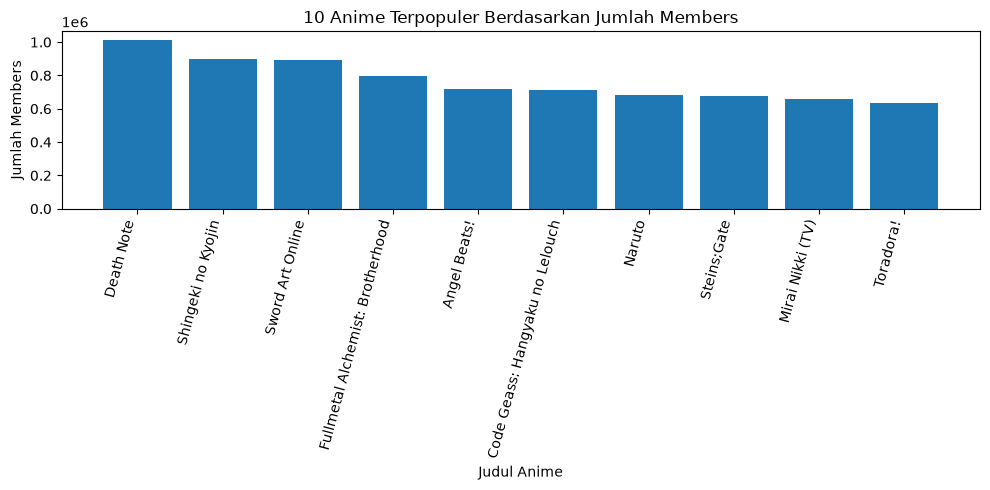

In [23]:

top_anime = anime.sort_values("members", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_anime["name"], top_anime["members"])
plt.xticks(rotation=75, ha="right")
plt.title("10 Anime Terpopuler Berdasarkan Jumlah Members")
plt.xlabel("Judul Anime")
plt.ylabel("Jumlah Members")
plt.tight_layout()
plt.show()


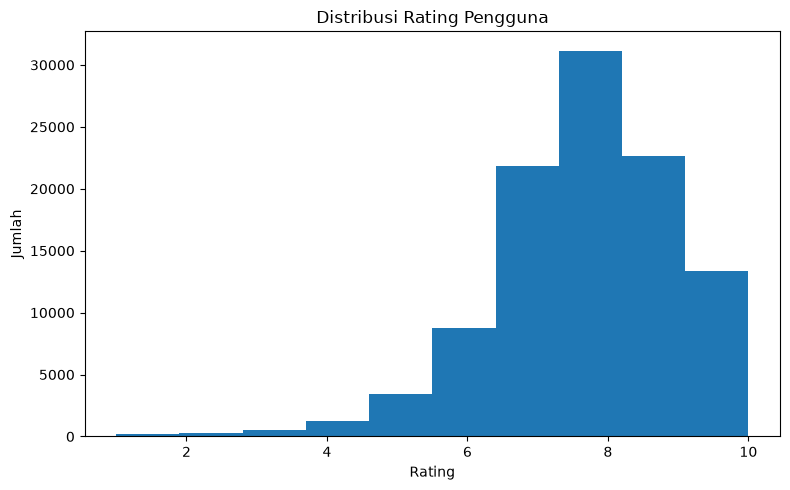

In [24]:

plt.figure(figsize=(8, 5))
plt.hist(rating["rating"], bins=10)
plt.title("Distribusi Rating Pengguna")
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()


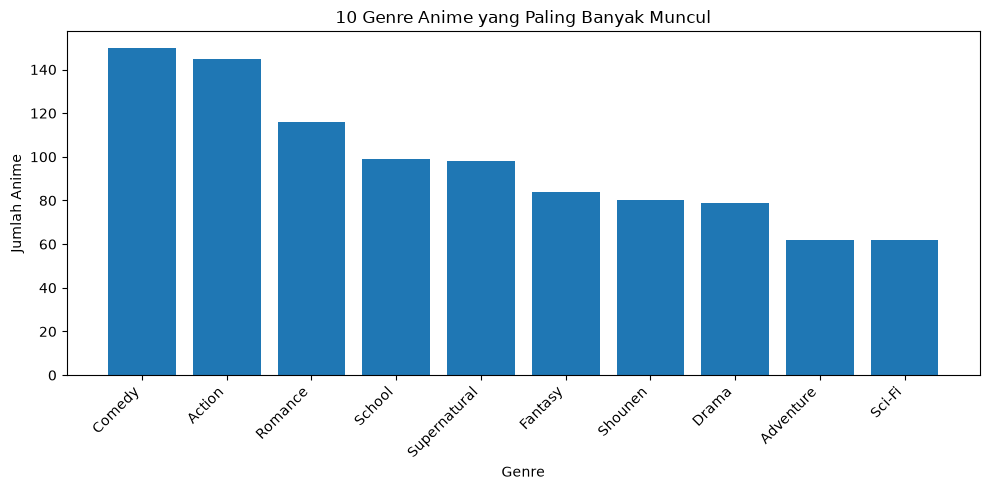

In [25]:

genre_series = anime["genre"].dropna().str.split(", ")
genre_exploded = genre_series.explode()
top_genres = genre_exploded.value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_genres.index, top_genres.values)
plt.xticks(rotation=45, ha="right")
plt.title("10 Genre Anime yang Paling Banyak Muncul")
plt.xlabel("Genre")
plt.ylabel("Jumlah Anime")
plt.tight_layout()
plt.show()



## 5. Data Preparation

Tahapan data preparation dilakukan agar data siap digunakan dalam proses pemodelan.

Tahapan yang dilakukan:
1. Mengisi nilai kosong pada kolom genre dan type.
2. Menghapus rating tidak valid.
3. Menghapus duplikasi data.
4. Membuat fitur gabungan untuk Content-Based Filtering.
5. Membagi data train dan test untuk evaluasi Collaborative Filtering.


In [26]:

anime_clean = anime.copy()
rating_clean = rating.copy()

anime_clean["genre"] = anime_clean["genre"].fillna("")
anime_clean["type"] = anime_clean["type"].fillna("")
anime_clean["name"] = anime_clean["name"].fillna("Unknown")

rating_clean = rating_clean[rating_clean["rating"] != -1]

anime_clean = anime_clean.drop_duplicates(subset=["anime_id"])
rating_clean = rating_clean.drop_duplicates(subset=["user_id", "anime_id"])

anime_clean["combined_features"] = (
    anime_clean["name"].astype(str) + " " +
    anime_clean["genre"].astype(str) + " " +
    anime_clean["type"].astype(str)
)

print("Data anime setelah dibersihkan:", anime_clean.shape)
print("Data rating setelah dibersihkan:", rating_clean.shape)

display(anime_clean.head())
display(rating_clean.head())


Data anime setelah dibersihkan: (300, 8)
Data rating setelah dibersihkan: (103449, 3)


,anime_id,name,genre,type,episodes,rating,members,combined_features
0,1535,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37,8.71,1013917,"Death Note Mystery, Police, Psychological, Sup..."
1,16498,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25,8.54,896229,"Shingeki no Kyojin Action, Drama, Fantasy, Sho..."
2,11757,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25,7.83,893100,"Sword Art Online Action, Adventure, Fantasy, G..."
3,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,"Fullmetal Alchemist: Brotherhood Action, Adven..."
4,6547,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13,8.39,717796,"Angel Beats! Action, Comedy, Drama, School, Su..."


,user_id,anime_id,rating
0,226,1,8
1,226,6,8
2,226,20,7
3,226,45,8
4,226,59,8


In [27]:

merged_data = rating_clean.merge(
    anime_clean,
    on="anime_id",
    how="inner",
    suffixes=("_user", "_anime")
)

print("Ukuran data setelah digabung:", merged_data.shape)
display(merged_data.head())


Ukuran data setelah digabung: (103449, 10)


,user_id,anime_id,rating_user,name,genre,type,episodes,rating_anime,members,combined_features
0,226,1,8,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,26,8.82,486824,"Cowboy Bebop Action, Adventure, Comedy, Drama,..."
1,226,6,8,Trigun,"Action, Comedy, Sci-Fi",TV,26,8.32,283069,"Trigun Action, Comedy, Sci-Fi TV"
2,226,20,7,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220,7.81,683297,"Naruto Action, Comedy, Martial Arts, Shounen, ..."
3,226,45,8,Rurouni Kenshin: Meiji Kenkaku Romantan,"Action, Adventure, Comedy, Historical, Romance...",TV,94,8.43,218928,Rurouni Kenshin: Meiji Kenkaku Romantan Action...
4,226,59,8,Chobits,"Comedy, Drama, Ecchi, Romance, Sci-Fi, Seinen",TV,26,7.57,266846,"Chobits Comedy, Drama, Ecchi, Romance, Sci-Fi,..."



## 6. Modeling and Results

Pada bagian ini dilakukan pemodelan menggunakan dua pendekatan:
1. Content-Based Filtering
2. Collaborative Filtering



### 6.1 Content-Based Filtering

Content-Based Filtering merekomendasikan anime berdasarkan kemiripan fitur anime. Pada proyek ini, fitur yang digunakan adalah gabungan dari judul, genre, dan tipe anime. Fitur teks tersebut diubah menjadi representasi numerik menggunakan TF-IDF, kemudian dihitung kemiripannya menggunakan Cosine Similarity.


In [28]:

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(anime_clean["combined_features"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Ukuran TF-IDF Matrix:", tfidf_matrix.shape)
print("Ukuran Cosine Similarity Matrix:", cosine_sim.shape)


Ukuran TF-IDF Matrix: (300, 570)
Ukuran Cosine Similarity Matrix: (300, 300)


In [29]:

indices = pd.Series(anime_clean.index, index=anime_clean["name"]).drop_duplicates()

def content_based_recommendation(anime_title, top_n=5):
    if anime_title not in indices:
        return pd.DataFrame()
    
    idx = indices[anime_title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]
    
    anime_indices = [i[0] for i in sim_scores]
    
    result = anime_clean.iloc[anime_indices][["anime_id", "name", "genre", "type", "rating", "members"]]
    return result

example_title = "Dragon Ball" if "Dragon Ball" in anime_clean["name"].values else anime_clean["name"].iloc[0]

print("Contoh rekomendasi untuk:", example_title)
display(content_based_recommendation(example_title, 5))


Contoh rekomendasi untuk: Dragon Ball


,anime_id,name,genre,type,rating,members
60,813,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,375662
171,225,Dragon Ball GT,"Action, Adventure, Comedy, Fantasy, Magic, Sci...",TV,6.72,226625
6,20,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81,683297
26,1735,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578
206,6594,Katanagatari,"Action, Adventure, Historical, Martial Arts, R...",TV,8.49,207241



### 6.2 Collaborative Filtering

Collaborative Filtering merekomendasikan anime berdasarkan pola rating pengguna. Pada proyek ini digunakan pendekatan user-based collaborative filtering. Sistem mencari pengguna lain yang memiliki pola rating mirip, kemudian merekomendasikan anime yang disukai oleh pengguna-pengguna serupa tersebut.


In [30]:

user_item_matrix = rating_clean.pivot_table(
    index="user_id",
    columns="anime_id",
    values="rating"
).fillna(0)

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print("Ukuran user-item matrix:", user_item_matrix.shape)
print("Ukuran user similarity matrix:", user_similarity_df.shape)


Ukuran user-item matrix: (500, 297)
Ukuran user similarity matrix: (500, 500)


In [31]:

def collaborative_recommendation(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        popular = anime_clean.sort_values("members", ascending=False).head(top_n)
        return popular[["anime_id", "name", "genre", "type", "rating", "members"]]
    
    similar_users = (
        user_similarity_df[user_id]
        .drop(index=user_id)
        .sort_values(ascending=False)
        .head(5)
    )
    
    similar_user_ratings = user_item_matrix.loc[similar_users.index]
    weighted_scores = np.dot(similar_users.values, similar_user_ratings)
    
    if similar_users.sum() != 0:
        weighted_scores = weighted_scores / similar_users.sum()
    
    recommendation_scores = pd.Series(
        weighted_scores,
        index=user_item_matrix.columns
    )
    
    watched_anime = user_item_matrix.loc[user_id]
    recommendation_scores = recommendation_scores[watched_anime == 0]
    
    top_anime_ids = recommendation_scores.sort_values(ascending=False).head(top_n).index
    
    result = anime_clean[anime_clean["anime_id"].isin(top_anime_ids)]
    result = result[["anime_id", "name", "genre", "type", "rating", "members"]]
    
    return result

example_user = rating_clean["user_id"].iloc[0]

print("Contoh rekomendasi untuk User ID:", example_user)
display(collaborative_recommendation(example_user, 5))


Contoh rekomendasi untuk User ID: 226


,anime_id,name,genre,type,rating,members
51,31043,Boku dake ga Inai Machi,"Mystery, Psychological, Seinen, Supernatural",TV,8.65,402381
66,31240,Re:Zero kara Hajimeru Isekai Seikatsu,"Drama, Fantasy, Psychological, Thriller",TV,8.64,355839
83,14345,Btooom!,"Action, Psychological, Sci-Fi, Seinen",TV,7.68,329561
120,31964,Boku no Hero Academia,"Action, Comedy, School, Shounen, Super Power",TV,8.36,282002
148,28907,"Gate: Jieitai Kanochi nite, Kaku Tatakaeri","Action, Adventure, Fantasy, Military",TV,7.97,244314



## 7. Evaluation

Evaluasi dilakukan sesuai karakteristik masing-masing pendekatan.

1. **Content-Based Filtering** dievaluasi dengan melihat kesesuaian genre antara anime input dan anime rekomendasi menggunakan Precision@K sederhana.
2. **Collaborative Filtering** dievaluasi menggunakan MAE dan RMSE untuk mengukur selisih antara rating aktual dan rating prediksi.


In [32]:

def genre_set(value):
    return set([g.strip() for g in str(value).split(",") if g.strip()])

def precision_at_k_content_based(anime_title, k=5):
    target_row = anime_clean[anime_clean["name"] == anime_title]
    
    if target_row.empty:
        return 0
    
    target_genres = genre_set(target_row.iloc[0]["genre"])
    recommendations = content_based_recommendation(anime_title, k)
    
    if recommendations.empty:
        return 0
    
    relevant_count = 0
    
    for genre in recommendations["genre"]:
        rec_genres = genre_set(genre)
        if len(target_genres.intersection(rec_genres)) > 0:
            relevant_count += 1
    
    return relevant_count / k

precision_k = precision_at_k_content_based(example_title, 5)

print(f"Precision@5 Content-Based Filtering untuk '{example_title}': {precision_k:.2f}")


Precision@5 Content-Based Filtering untuk 'Dragon Ball': 1.00


In [33]:

train_data, test_data = train_test_split(
    rating_clean,
    test_size=0.2,
    random_state=42
)

train_matrix = train_data.pivot_table(
    index="user_id",
    columns="anime_id",
    values="rating"
).fillna(0)

train_similarity = cosine_similarity(train_matrix)

train_similarity_df = pd.DataFrame(
    train_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

global_mean = train_data["rating"].mean()
anime_mean = train_data.groupby("anime_id")["rating"].mean()

def predict_rating(user_id, anime_id, max_neighbors=20):
    if user_id not in train_matrix.index:
        return global_mean
    
    if anime_id not in train_matrix.columns:
        return anime_mean.get(anime_id, global_mean)
    
    user_sims = train_similarity_df.loc[user_id].drop(index=user_id, errors="ignore")
    anime_ratings = train_matrix[anime_id]
    
    rated_users = anime_ratings[anime_ratings > 0].index
    user_sims = user_sims.loc[user_sims.index.intersection(rated_users)]
    
    if user_sims.empty or user_sims.sum() == 0:
        return anime_mean.get(anime_id, global_mean)
    
    top_sims = user_sims.sort_values(ascending=False).head(max_neighbors)
    top_ratings = anime_ratings.loc[top_sims.index]
    
    prediction = np.dot(top_sims.values, top_ratings.values) / top_sims.sum()
    return prediction

test_sample = test_data.sample(n=min(5000, len(test_data)), random_state=42)

predictions = [
    predict_rating(row.user_id, row.anime_id)
    for row in test_sample.itertuples(index=False)
]

mae = mean_absolute_error(test_sample["rating"], predictions)
rmse = np.sqrt(mean_squared_error(test_sample["rating"], predictions))

print(f"MAE Collaborative Filtering: {mae:.4f}")
print(f"RMSE Collaborative Filtering: {rmse:.4f}")


MAE Collaborative Filtering: 0.9960
RMSE Collaborative Filtering: 1.3128



### Hasil Evaluasi

- **Content-Based Filtering** mampu memberikan rekomendasi berdasarkan kemiripan genre, judul, dan tipe anime.
- **Collaborative Filtering** mampu memberikan rekomendasi yang lebih personal karena mempertimbangkan pola rating pengguna.
- Nilai MAE dan RMSE digunakan untuk melihat tingkat kesalahan prediksi rating pada Collaborative Filtering. Semakin kecil nilai MAE dan RMSE, maka semakin baik performa model dalam memprediksi rating.



## 8. Deployment

Deployment dilakukan menggunakan **Streamlit** melalui file `app.py`. Aplikasi yang dibuat menyediakan dua menu utama:

1. **Content-Based Filtering**  
   Pengguna memilih judul anime, kemudian sistem menampilkan anime yang mirip berdasarkan judul, genre, dan tipe.

2. **Collaborative Filtering**  
   Pengguna memilih User ID, kemudian sistem menampilkan rekomendasi anime berdasarkan pola rating pengguna lain yang mirip.

File pendukung deployment:
- `app.py`
- `requirements.txt`
- `data_sample/anime_sample.csv`
- `data_sample/rating_sample.csv`

Aplikasi dapat dijalankan dengan perintah:

`python -m streamlit run app.py`



## 9. Kesimpulan

Berdasarkan hasil proyek, sistem rekomendasi anime berhasil dibangun menggunakan dua pendekatan, yaitu Content-Based Filtering dan Collaborative Filtering.

**Content-Based Filtering** cocok digunakan untuk memberikan rekomendasi berdasarkan kemiripan fitur anime seperti genre, judul, dan tipe. Pendekatan ini tidak membutuhkan data rating pengguna yang banyak, tetapi rekomendasinya terbatas pada kemiripan konten.

**Collaborative Filtering** mampu memberikan rekomendasi yang lebih personal karena memanfaatkan pola rating dari pengguna lain. Namun, pendekatan ini membutuhkan data interaksi pengguna yang cukup agar hasil rekomendasi lebih baik.

Secara keseluruhan, kedua pendekatan memiliki kelebihan masing-masing. Pengembangan selanjutnya dapat dilakukan dengan menggabungkan keduanya menjadi hybrid recommender system agar rekomendasi menjadi lebih akurat dan relevan.
